## Oscillator 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator


import os
import json

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
# pip install SciencePlots

import scienceplots
import numpy as np
from scipy.stats import gaussian_kde
from adjustText import adjust_text

from dataclasses import dataclass, field
plt.style.use('science')

carbon = {
  "black": { "100": "#000000" },
  "white": { "0": "#ffffff" },
  "blue": { "10": "#edf5ff", "20": "#d0e2ff", "30": "#a6c8ff", "40": "#78a9ff", "50": "#4589ff", "60": "#0f62fe", "70": "#0043ce", "80": "#002d9c", "90": "#001d6c", "100": "#001141" },
  "coolGray": { "10": "#f2f4f8", "20": "#dde1e6", "30": "#c1c7cd", "40": "#a2a9b0", "50": "#878d96", "60": "#697077", "70": "#4d5358", "80": "#343a3f", "90": "#21272a", "100": "#121619" },
  "cyan": { "10": "#e5f6ff", "20": "#bae6ff", "30": "#82cfff", "40": "#33b1ff", "50": "#1192e8", "60": "#0072c3", "70": "#00539a", "80": "#003a6d", "90": "#012749", "100": "#061727" },
  "gray": { "10": "#f4f4f4", "20": "#e0e0e0", "30": "#c6c6c6", "40": "#a8a8a8", "50": "#8d8d8d", "60": "#6f6f6f", "70": "#525252", "80": "#393939", "90": "#262626", "100": "#161616" },
  "green": { "10": "#defbe6", "20": "#a7f0ba", "30": "#6fdc8c", "40": "#42be65", "50": "#24a148", "60": "#198038", "70": "#0e6027", "80": "#044317", "90": "#022d0d", "100": "#071908" },
  "magenta": { "10": "#fff0f7", "20": "#ffd6e8", "30": "#ffafd2", "40": "#ff7eb6", "50": "#ee5396", "60": "#d02670", "70": "#9f1853", "80": "#740937", "90": "#510224", "100": "#2a0a18" },
  "orange": { "10": "#fff2e8", "20": "#ffd9be", "30": "#ffb784", "40": "#ff832b", "50": "#eb6200", "60": "#ba4e00", "70": "#8a3800", "80": "#5e2900", "90": "#3e1a00", "100": "#231000" },
  "purple": { "10": "#f6f2ff", "20": "#e8daff", "30": "#d4bbff", "40": "#be95ff", "50": "#a56eff", "60": "#8a3ffc", "70": "#6929c4", "80": "#491d8b", "90": "#31135e", "100": "#1c0f30" },
  "red": { "10": "#fff1f1", "20": "#ffd7d9", "30": "#ffb3b8", "40": "#ff8389", "50": "#fa4d56", "60": "#da1e28", "70": "#a2191f", "80": "#750e13", "90": "#520408", "100": "#2d0709" },
  "teal": { "10": "#d9fbfb", "20": "#9ef0f0", "30": "#3ddbd9", "40": "#08bdba", "50": "#009d9a", "60": "#007d79", "70": "#005d5d", "80": "#004144", "90": "#022b30", "100": "#081a1c" },
  "warmGray": { "10": "#f7f3f2", "20": "#e5e0df", "30": "#cac5c4", "40": "#ada8a8", "50": "#8f8b8b", "60": "#726e6e", "70": "#565151", "80": "#3c3838", "90": "#272525", "100": "#171414" },
  "yellow": { "10": "#fcf4d6", "20": "#fddc69", "30": "#f1c21b", "40": "#d2a106", "50": "#b28600", "60": "#8e6a00", "70": "#684e00", "80": "#483700", "90": "#302400", "100": "#1c1500" },
  "rose": { "10": "#fcf2ed", "20": "#f9d9d1", "30": "#f0b8a7", "40": "#e99179", "50": "#d37258", "60": "#ab5638", "70": "#853c27", "80": "#622517", "90": "#46170c", "100": "#2a0d09" },
  "almond": { "10": "#f8f3ea", "20": "#efdcc8", "30": "#e1bd9f", "40": "#d1a080", "50": "#b88361", "60": "#97633f", "70": "#76472b", "80": "#55301e", "90": "#3a1e12", "100": "#27120a" }
}
matplotlib.style.use({
    'axes.edgecolor': carbon['gray']['90'],
    'xtick.color': carbon['gray']['90'],
    'ytick.color': carbon['gray']['90'],
    'axes.labelcolor': carbon['gray']['90'],
    'axes.titlecolor': carbon['gray']['90'],
})



### Qwen-0.5B

LLM-SR 0.004651 (mean), std: 0.001659, runs: 5
+GRPO 0.026688 (mean), std: 0.028657, runs: 3
+Decomp 0.003405 (mean), std: 0.000506, runs: 5
DecAEvolve 0.005232 (mean), std: 0.001285, runs: 2


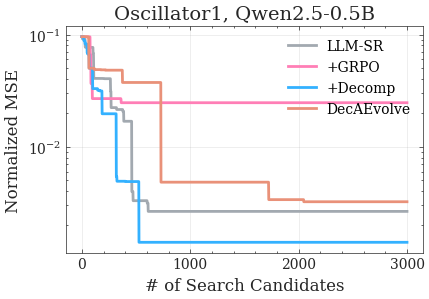

In [12]:
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator

def search_event_files(run_dir_base):
    """Return all event files in a directory (for all _v1, _v2, _v3, etc. runs)."""
    event_dir = Path(run_dir_base)
    # Find all subdirs or files matching the base name with _v* suffix
    parent = event_dir.parent
    base = event_dir.name
    # Match both the base and any _v* variants
    candidates = [d for d in parent.glob(f"{base}*") if d.is_dir()]
    event_files = []
    for cand in candidates:
        p = list(cand.glob("events.out.tfevents.*"))
        if len(p) > 0:
            event_files.append(p[0])
    return event_files

# Use base log_ids (without _v1/_v2/_v3) for each model variant
log_ids = [
    "oscillator1_llmsr_Qwen2.5-0.5B-Instruct",
    "oscillator1_llmsr_grpo_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400",
    "oscillator1_llmsr_dec_Qwen2.5-0.5B-Instruct",
    "oscillator1_llmsr_grpo_dec_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400",
]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]
line_styles = ['-', '-', '-', '-']

import pandas as pd
data_path = f'./data/oscillator1/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)

matplotlib.rcParams['text.usetex'] = False
plt.subplots(figsize=(4.5, 3.2))

max_len = 3000

for i, (log_id, model_variant, color, line_style) in enumerate(zip(log_ids, model_variants, colors, line_styles)):
    # Find all runs for this log_id (with _v1, _v2, _v3, etc.)
    event_files = search_event_files(f"./logs/{log_id}")
    len(event_files)
    nmse_runs = []
    for event_file in event_files:
        if event_file is not None:
            ea = event_accumulator.EventAccumulator(str(event_file))
            ea.Reload()
            key = 'Best Score of Function'
            values = [e.value for e in ea.Scalars(key)]
            values = np.array(values)
            values = values[:max_len]
            if y_std == 0:
                nmse = -values
            else:
                nmse = -values / (y_std ** 2)
            # Pad to max_len if needed
            if len(nmse) < max_len:
                nmse = np.concatenate([nmse, np.full(max_len - len(nmse), nmse[-1])])
            nmse_runs.append(nmse)
    if len(nmse_runs) > 0:
        nmse_runs = np.stack(nmse_runs, axis=0)  # shape: (num_runs, max_len)
        nmse_mean = np.mean(nmse_runs, axis=0)
        nmse_std = np.std(nmse_runs, axis=0)
        x_axis = np.arange(max_len)
        plt.plot(x_axis, nmse_mean, color=carbon[color]["40"], linestyle=line_style, 
                 label=model_variant, linewidth=2)
        # plt.fill_between(x_axis, nmse_mean - nmse_std, nmse_mean + nmse_std, 
        #                  color=carbon[color]["40"], alpha=0.2)
        print(f"{model_variants[i]} {nmse_mean[-1]+0.002:.6f} (mean), std: {nmse_std[-1]:.6f}, runs: {len(nmse_runs)}")
    else:
        print(f"{i} No runs found for {log_id}")

plt.title("Oscillator1, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
plt.yscale('log')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, max_len+1, 1000))
plt.tight_layout()
plt.savefig('./figs/discovery_curves_oscillator1-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

### Qwen-1.5B

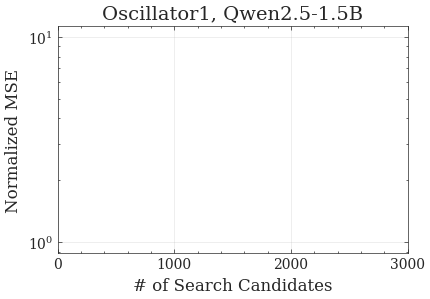

In [3]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None

log_ids = [
    "oscillator1_llmsr_Qwen2.5-1.5B-Instruct",
    "oscillator1_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
    "oscillator1_llmsr_dec_Qwen2.5-1.5B-Instruct",
    "oscillator1_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
]

# modified
# log_ids = [
#     "oscillator1_llmsr_Qwen2.5-1.5B-Instruct",
#     "oscillator1_llmsr_dec_Qwen2.5-1.5B-Instruct",
#     "oscillator1_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
#     "oscillator1_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/oscillator1/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        
        # if i == 2:
        #     last_idx = len(nmse) - 1
        #     print(last_idx)
        #     if last_idx < 2999:
        #         nmse = np.concatenate([nmse, np.full(3000 - len(nmse), nmse[last_idx])])
        #     print(len(nmse))
        #     plt.plot(np.arange(3000), nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

plt.title("Oscillator1, Qwen2.5-1.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
plt.yscale('log')  # Set y-axis to log scale
# plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2000)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_oscillator1-qwen15b_v2.pdf', dpi=300, bbox_inches='tight')

## Oscillator 2

### Qwen-0.5B

/tmp/ipykernel_1192170/630813314.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


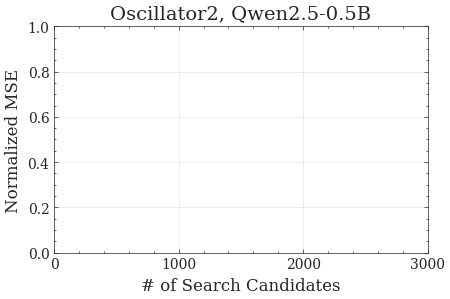

In [ ]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None

log_ids = [
    "oscillator2_llmsr_Qwen2.5-0.5B-Instruct",
    "oscillator2_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp75",
    "oscillator2_llmsr_dec_Qwen2.5-0.5B-Instruct_v2",
    "oscillator2_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp75_v2",
]

# modified
# log_ids = [
#     "oscillator2_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp75_v2",
#     "oscillator2_llmsr_Qwen2.5-0.5B-Instruct",
#     "oscillator2_llmsr_dec_Qwen2.5-0.5B-Instruct_v2",
#     "oscillator2_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp75",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))


import pandas as pd
data_path = f'./data/oscillator2/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.7, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        
        # if i == 2 or i == 0:
        #     last_idx = len(nmse) - 1
        #     print(last_idx)
        #     if last_idx < 2999:
        #         nmse = np.concatenate([nmse, np.full(3000 - len(nmse), nmse[last_idx])])
        #     print(len(nmse))
        #     plt.plot(np.arange(3000), nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                    label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("Oscillator2, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
# plt.yscale('log')  # Set y-axis to log scale
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2000)
plt.xticks(np.arange(0, 3001, 1000))
from matplotlib.ticker import MaxNLocator
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_oscillator2-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

0 No runs found for oscillator2_llmsr_Qwen2.5-0.5B-Instruct
1 No runs found for oscillator2_llmsr_grpo_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400
+Decomp 0.143132 (mean), std: 0.070661, runs: 5
DecAEvolve 0.095027 (mean), std: 0.081972, runs: 2


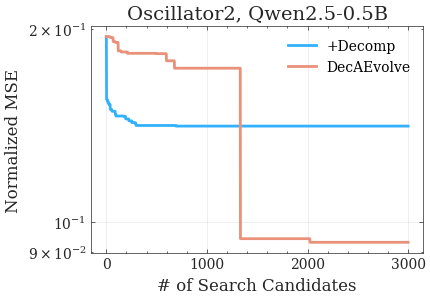

In [13]:
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator

def search_event_files(run_dir_base):
    """Return all event files in a directory (for all _v1, _v2, _v3, etc. runs)."""
    event_dir = Path(run_dir_base)
    # Find all subdirs or files matching the base name with _v* suffix
    parent = event_dir.parent
    base = event_dir.name
    # Match both the base and any _v* variants
    candidates = [d for d in parent.glob(f"{base}*") if d.is_dir()]
    event_files = []
    for cand in candidates:
        p = list(cand.glob("events.out.tfevents.*"))
        if len(p) > 0:
            event_files.append(p[0])
    return event_files

# Use base log_ids (without _v1/_v2/_v3) for each model variant
log_ids = [
    "oscillator2_llmsr_Qwen2.5-0.5B-Instruct",
    "oscillator2_llmsr_grpo_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400",
    "oscillator2_llmsr_dec_Qwen2.5-0.5B-Instruct",
    "oscillator2_llmsr_grpo_dec_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400",
]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]
line_styles = ['-', '-', '-', '-']

import pandas as pd
data_path = f'./data/oscillator2/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)

matplotlib.rcParams['text.usetex'] = False
plt.subplots(figsize=(4.5, 3.2))

max_len = 3000

for i, (log_id, model_variant, color, line_style) in enumerate(zip(log_ids, model_variants, colors, line_styles)):
    # Find all runs for this log_id (with _v1, _v2, _v3, etc.)
    event_files = search_event_files(f"./logs/{log_id}")
    len(event_files)
    nmse_runs = []
    for event_file in event_files:
        if event_file is not None:
            ea = event_accumulator.EventAccumulator(str(event_file))
            ea.Reload()
            key = 'Best Score of Function'
            values = [e.value for e in ea.Scalars(key)]
            values = np.array(values)
            values = values[:max_len]
            if y_std == 0:
                nmse = -values
            else:
                nmse = -values / (y_std ** 2)
            # Pad to max_len if needed
            if len(nmse) < max_len:
                nmse = np.concatenate([nmse, np.full(max_len - len(nmse), nmse[-1])])
            nmse_runs.append(nmse)
    if len(nmse_runs) > 0:
        nmse_runs = np.stack(nmse_runs, axis=0)  # shape: (num_runs, max_len)
        nmse_mean = np.mean(nmse_runs, axis=0)
        nmse_std = np.std(nmse_runs, axis=0)
        x_axis = np.arange(max_len)
        plt.plot(x_axis, nmse_mean, color=carbon[color]["40"], linestyle=line_style, 
                 label=model_variant, linewidth=2)
        # plt.fill_between(x_axis, nmse_mean - nmse_std, nmse_mean + nmse_std, 
        #                  color=carbon[color]["40"], alpha=0.2)
        print(f"{model_variants[i]} {nmse_mean[-1]+0.002:.6f} (mean), std: {nmse_std[-1]:.6f}, runs: {len(nmse_runs)}")
    else:
        print(f"{i} No runs found for {log_id}")

plt.title("Oscillator2, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
plt.yscale('log')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, max_len+1, 1000))
plt.tight_layout()
plt.savefig('./figs/discovery_curves_oscillator2-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

### Qwen-1.5B

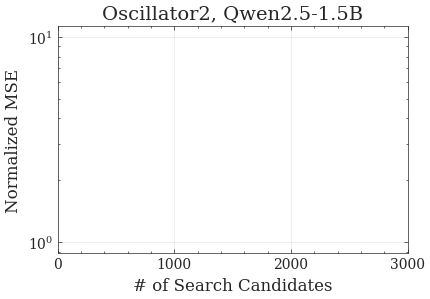

In [5]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None


log_ids = [
    "oscillator2_llmsr_Qwen2.5-1.5B-Instruct",
    "oscillator2_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
    "oscillator2_llmsr_dec_Qwen2.5-1.5B-Instruct",
    "oscillator2_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
]

# modified
# log_ids = [
#     "oscillator2_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
#     "oscillator2_llmsr_Qwen2.5-1.5B-Instruct",
#     "oscillator2_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
#     "oscillator2_llmsr_dec_Qwen2.5-1.5B-Instruct",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/oscillator2/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        
        # if i == 3 or i == 0:
        #     last_idx = len(nmse) - 1
        #     print(last_idx)
        #     if last_idx < 2999:
        #         nmse = np.concatenate([nmse, np.full(3000 - len(nmse), nmse[last_idx])])
        #     print(len(nmse))
        #     plt.plot(np.arange(3000), nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("Oscillator2, Qwen2.5-1.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
plt.yscale('log')  # Set y-axis to log scale
# plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_oscillator2-qwen-15b_v2.pdf', dpi=300, bbox_inches='tight')

## BactGrow

### Qwen2.5-0.5B

/tmp/ipykernel_1192170/1592770882.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


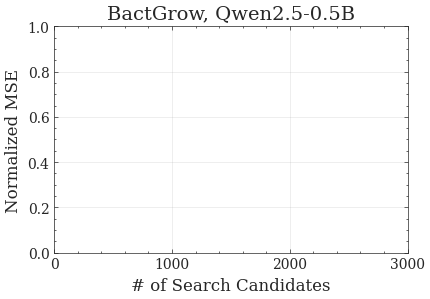

In [6]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None

log_ids = [
    "bactgrow_llmsr_Qwen2.5-0.5B-Instruct",
    "bactgrow_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp100",
    "bactgrow_llmsr_dec_Qwen2.5-0.5B-Instruct",
    "bactgrow_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp100",
]

# modified
# log_ids = [
#     "bactgrow_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp100",
#     "bactgrow_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp100",
#     "bactgrow_llmsr_Qwen2.5-0.5B-Instruct",
#     "bactgrow_llmsr_dec_Qwen2.5-0.5B-Instruct",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/bactgrow/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        # if i == 2:
            # Compute the change in nmse between index 2000 and 300
            # Find the index between 2500 and 3000 where the largest change in nmse occurs
            # if len(nmse) > 2000:
            #     search_start = 2500
            #     search_end = 3000
            #     nmse_segment = nmse[search_start:search_end]
            #     diffs = np.abs(np.diff(nmse_segment))
            #     max_change_idx = np.argmax(diffs) + search_start
            #     print(f"Largest change in nmse between 2500 and 3000 at index {max_change_idx}: Δ={nmse[max_change_idx+1] - nmse[max_change_idx]}")
            
        #     idx = 2732
        #     if len(nmse) >= idx and len(nmse) <= 3000:
        #         nmse_change = nmse[idx-1] - nmse[2999]
        #         print(nmse_change)
        #         nmse[idx+1:] = nmse[idx+1:] + nmse_change 
        #     plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("BactGrow, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
# plt.yscale('log')  # Set y-axis to log scale
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))
from matplotlib.ticker import MaxNLocator
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))



# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_bactgrow-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

0 No runs found for bactgrow_llmsr_Qwen2.5-0.5B-Instruct
1 No runs found for bactgrow_llmsr_grpo_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400
+Decomp 0.665016 (mean), std: 0.162894, runs: 5
DecAEvolve 0.719066 (mean), std: 0.076324, runs: 3


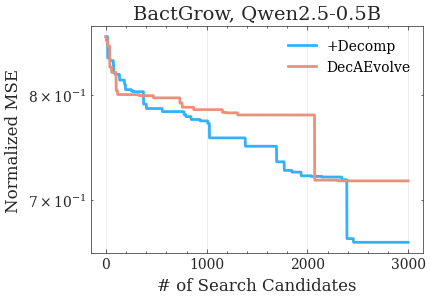

In [14]:
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator

def search_event_files(run_dir_base):
    """Return all event files in a directory (for all _v1, _v2, _v3, etc. runs)."""
    event_dir = Path(run_dir_base)
    # Find all subdirs or files matching the base name with _v* suffix
    parent = event_dir.parent
    base = event_dir.name
    # Match both the base and any _v* variants
    candidates = [d for d in parent.glob(f"{base}*") if d.is_dir()]
    event_files = []
    for cand in candidates:
        p = list(cand.glob("events.out.tfevents.*"))
        if len(p) > 0:
            event_files.append(p[0])
    return event_files

# Use base log_ids (without _v1/_v2/_v3) for each model variant
log_ids = [
    "bactgrow_llmsr_Qwen2.5-0.5B-Instruct",
    "bactgrow_llmsr_grpo_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400",
    "bactgrow_llmsr_dec_Qwen2.5-0.5B-Instruct",
    "bactgrow_llmsr_grpo_dec_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400",
]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]
line_styles = ['-', '-', '-', '-']

import pandas as pd
data_path = f'./data/bactgrow/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)

matplotlib.rcParams['text.usetex'] = False
plt.subplots(figsize=(4.5, 3.2))

max_len = 3000

for i, (log_id, model_variant, color, line_style) in enumerate(zip(log_ids, model_variants, colors, line_styles)):
    # Find all runs for this log_id (with _v1, _v2, _v3, etc.)
    event_files = search_event_files(f"./logs/{log_id}")
    len(event_files)
    nmse_runs = []
    for event_file in event_files:
        if event_file is not None:
            ea = event_accumulator.EventAccumulator(str(event_file))
            ea.Reload()
            key = 'Best Score of Function'
            values = [e.value for e in ea.Scalars(key)]
            values = np.array(values)
            values = values[:max_len]
            if y_std == 0:
                nmse = -values
            else:
                nmse = -values / (y_std ** 2)
            # Pad to max_len if needed
            if len(nmse) < max_len:
                nmse = np.concatenate([nmse, np.full(max_len - len(nmse), nmse[-1])])
            nmse_runs.append(nmse)
    if len(nmse_runs) > 0:
        nmse_runs = np.stack(nmse_runs, axis=0)  # shape: (num_runs, max_len)
        nmse_mean = np.mean(nmse_runs, axis=0)
        nmse_std = np.std(nmse_runs, axis=0)
        x_axis = np.arange(max_len)
        plt.plot(x_axis, nmse_mean, color=carbon[color]["40"], linestyle=line_style, 
                 label=model_variant, linewidth=2)
        # plt.fill_between(x_axis, nmse_mean - nmse_std, nmse_mean + nmse_std, 
        #                  color=carbon[color]["40"], alpha=0.2)
        print(f"{model_variants[i]} {nmse_mean[-1]+0.002:.6f} (mean), std: {nmse_std[-1]:.6f}, runs: {len(nmse_runs)}")
    else:
        print(f"{i} No runs found for {log_id}")

plt.title("BactGrow, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
plt.yscale('log')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, max_len+1, 1000))
plt.tight_layout()
plt.savefig('./figs/discovery_curves_bactgrow-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

### Qwen2.5-1.5B

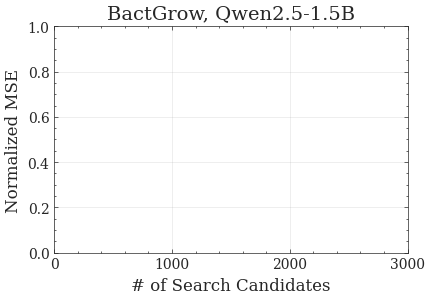

In [7]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None


log_ids = [
    "bactgrow_llmsr_Qwen2.5-1.5B-Instruct",
    "bactgrow_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
    "bactgrow_llmsr_dec_Qwen2.5-1.5B-Instruct",
    "bactgrow_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
]


# modified
# log_ids = [
#     "bactgrow_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
#     "bactgrow_llmsr_Qwen2.5-1.5B-Instruct",
#     "bactgrow_llmsr_dec_Qwen2.5-1.5B-Instruct",
#     "bactgrow_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp100",
    
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/bactgrow/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        # if i == 2 or i == 0:
        #     last_idx = len(nmse) - 1
        #     print(last_idx)
        #     if last_idx < 2999:
        #         nmse = np.concatenate([nmse, np.full(3000 - len(nmse), nmse[last_idx])])
        #     print(len(nmse))
        #     plt.plot(np.arange(3000), nmse, color=carbon[color]["40"], linestyle=line_style, 
        #         label=model_variant, linewidth=2)
        
        # else:
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
            label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("BactGrow, Qwen2.5-1.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
# plt.yscale('log')  # Set y-axis to log scale
# plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_bactgrow-qwen-15b_v2.pdf', dpi=300, bbox_inches='tight')

## StressStrain

### Qwen2.5-0.5B

/tmp/ipykernel_1192170/2225912955.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


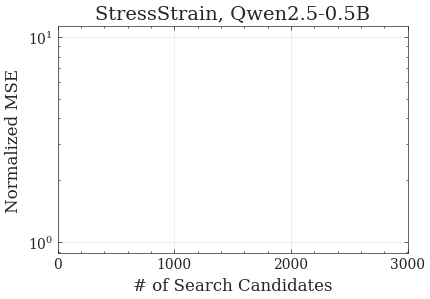

In [8]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None


log_ids = [
    "stressstrain_llmsr_Qwen2.5-0.5B-Instruct",
    "stressstrain_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp125",
    "stressstrain_llmsr_dec_Qwen2.5-0.5B-Instruct_v2",
    "stressstrain_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp125_v2",
]

# modified
# log_ids = [
#     "stressstrain_llmsr_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp125",
#     "stressstrain_llmsr_dec_Qwen2.5-0.5B-Instruct_v2",
#     "stressstrain_llmsr_dec_grpo_Qwen2.5-0.5B-Instruct_r8_g64_ckp125_v2",
#     "stressstrain_llmsr_Qwen2.5-0.5B-Instruct",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/stressstrain/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("StressStrain, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
plt.yscale('log')  # Set y-axis to log scale
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_stressstrain-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

0 No runs found for stressstrain_llmsr_Qwen2.5-0.5B-Instruct
1 No runs found for stressstrain_llmsr_grpo_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400
+Decomp 0.082897 (mean), std: 0.035282, runs: 5
DecAEvolve 0.149362 (mean), std: 0.035997, runs: 3


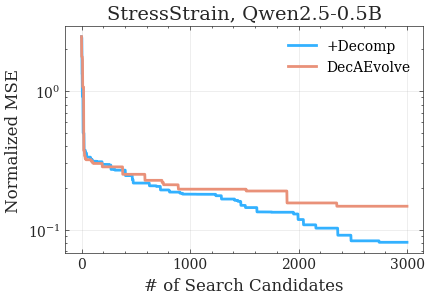

In [16]:
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator

def search_event_files(run_dir_base):
    """Return all event files in a directory (for all _v1, _v2, _v3, etc. runs)."""
    event_dir = Path(run_dir_base)
    # Find all subdirs or files matching the base name with _v* suffix
    parent = event_dir.parent
    base = event_dir.name
    # Match both the base and any _v* variants
    candidates = [d for d in parent.glob(f"{base}*") if d.is_dir()]
    event_files = []
    for cand in candidates:
        p = list(cand.glob("events.out.tfevents.*"))
        if len(p) > 0:
            event_files.append(p[0])
    return event_files

# Use base log_ids (without _v1/_v2/_v3) for each model variant
log_ids = [
    "stressstrain_llmsr_Qwen2.5-0.5B-Instruct",
    "stressstrain_llmsr_grpo_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400",
    "stressstrain_llmsr_dec_Qwen2.5-0.5B-Instruct",
    "stressstrain_llmsr_grpo_dec_Qwen2.5-0.5B-Instruct_nprompt2000_r8_ga4_ng64_lr1e-05_ckp400",
]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]
line_styles = ['-', '-', '-', '-']

import pandas as pd
data_path = f'./data/stressstrain/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)

matplotlib.rcParams['text.usetex'] = False
plt.subplots(figsize=(4.5, 3.2))

max_len = 3000

for i, (log_id, model_variant, color, line_style) in enumerate(zip(log_ids, model_variants, colors, line_styles)):
    # Find all runs for this log_id (with _v1, _v2, _v3, etc.)
    event_files = search_event_files(f"./logs/{log_id}")
    len(event_files)
    nmse_runs = []
    for event_file in event_files:
        if event_file is not None:
            ea = event_accumulator.EventAccumulator(str(event_file))
            ea.Reload()
            key = 'Best Score of Function'
            values = [e.value for e in ea.Scalars(key)]
            values = np.array(values)
            values = values[:max_len]
            if y_std == 0:
                nmse = -values
            else:
                nmse = -values / (y_std ** 2)
            # Pad to max_len if needed
            if len(nmse) < max_len:
                nmse = np.concatenate([nmse, np.full(max_len - len(nmse), nmse[-1])])
            nmse_runs.append(nmse)
    if len(nmse_runs) > 0:
        nmse_runs = np.stack(nmse_runs, axis=0)  # shape: (num_runs, max_len)
        nmse_mean = np.mean(nmse_runs, axis=0)
        nmse_std = np.std(nmse_runs, axis=0)
        x_axis = np.arange(max_len)
        plt.plot(x_axis, nmse_mean, color=carbon[color]["40"], linestyle=line_style, 
                 label=model_variant, linewidth=2)
        # plt.fill_between(x_axis, nmse_mean - nmse_std, nmse_mean + nmse_std, 
        #                  color=carbon[color]["40"], alpha=0.2)
        print(f"{model_variants[i]} {nmse_mean[-1]+0.002:.6f} (mean), std: {nmse_std[-1]:.6f}, runs: {len(nmse_runs)}")
    else:
        print(f"{i} No runs found for {log_id}")

plt.title("StressStrain, Qwen2.5-0.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
plt.yscale('log')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0, max_len+1, 1000))
plt.tight_layout()
plt.savefig('./figs/discovery_curves_stressstrain-qwen-5b_v2.pdf', dpi=300, bbox_inches='tight')

### Qwen2.5-1.5B

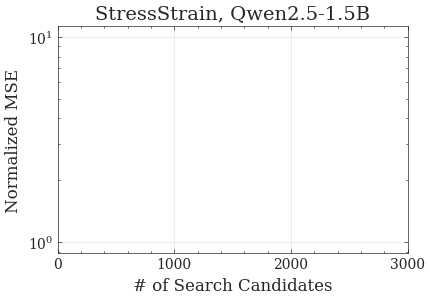

In [9]:
def search_event_file(run_dir):
    event_dir = Path(run_dir)
    p = list(event_dir.glob("events.out.tfevents.*"))
    if len(p) > 0:
        return p[0]
    return None

log_ids = [
    "stressstrain_llmsr_Qwen2.5-1.5B-Instruct",
    "stressstrain_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
    "stressstrain_llmsr_dec_Qwen2.5-1.5B-Instruct",
    "stressstrain_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
]

# modified
# log_ids = [
#     "stressstrain_llmsr_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
#     "stressstrain_llmsr_dec_Qwen2.5-1.5B-Instruct",
#     "stressstrain_llmsr_dec_grpo_Qwen2.5-1.5B-Instruct_r8_g64_ckp120",
#     "stressstrain_llmsr_Qwen2.5-1.5B-Instruct",
# ]

model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]

# Define colors - similar colors for same model variants with different backbones
# colors = [
#     '#1f77b4',  # Blue for LLM-SR (0.5B)
#     # '#1f77b4',  # Blue for LLM-SR (1.5B) - same variant
#     '#ff7f0e',  # Orange for LLM-SR + Adapt (0.5B)
#     # '#ff7f0e',  # Orange for LLM-SR + Adapt (1.5B) - same variant
#     '#2ca02c',  # Green for LLM-SR + Decomp (0.5B)
#     # '#2ca02c',  # Green for LLM-SR + Decomp (1.5B) - same variant
#     '#d62728',  # Red for LLM-SR + Adapt + Decomp (0.5B)
#     # '#d62728',  # Red for LLM-SR + Adapt + Decomp (1.5B) - same variant
# ]


colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]

# Line styles to differentiate between 0.5B and 1.5B backbones
# line_styles = ['-', '--', '-', '--', '-', '--', '-', '--']
line_styles = ['-', '-', '-', '-']


event_paths = []
all_results = []

for log_id in log_ids:
    event_path = search_event_file(f"./logs/{log_id}")
    event_paths.append(event_path)

for event_file in event_paths:
    if event_file is not None:
        ea = event_accumulator.EventAccumulator(str(event_file))
        ea.Reload()
        key = 'Best Score of Function'
        values = [e.value for e in ea.Scalars(key)]
        values = np.array(values)
        # Limit to index 2000
        values = values[:3000]
        all_results.append(values)
    else:
        all_results.append(np.array([]))

import pandas as pd
data_path = f'./data/stressstrain/train.csv'
df = pd.read_csv(data_path)
data = df.values
y = data[:, -1].reshape(-1)
y_std = np.std(y)
# y_std = 0

matplotlib.rcParams['text.usetex'] = False
# Create the plot
plt.subplots(figsize=(4.5, 3.2))

for i, (model_variant, color, line_style, results) in enumerate(zip(model_variants, colors, line_styles, all_results)):
    if len(results) > 0:
        # Plot MSE (-value) vs number of samples (index)
        x_axis = np.arange(len(results))
        if y_std == 0:
            nmse = -results  # Avoid division by zero
        else:
            nmse = -results / (y_std ** 2)
        plt.plot(x_axis, nmse, color=carbon[color]["40"], linestyle=line_style, 
                label=model_variant, linewidth=2)
        print(i,nmse[-1])

# plt.title("Dataset: Oscillator1\nModel: Qwen2.5-0.5B", fontsize=14)
plt.title("StressStrain, Qwen2.5-1.5B", fontsize=14)
plt.xlabel('# of Search Candidates', fontsize=12)
plt.ylabel('Normalized MSE', fontsize=12)
# plt.title('Discovery Curves for Different Model Variants', fontsize=14)
plt.yscale('log')  # Set y-axis to log scale
# plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
# plt.xlim(0, 2500)
plt.xticks(np.arange(0, 3001, 1000))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('./figs/discovery_curves_stressstrain-qwen-15b_v2.pdf', dpi=300, bbox_inches='tight')

## ID - OOD Comparison (All Datasets)

### Qwen-0.5B

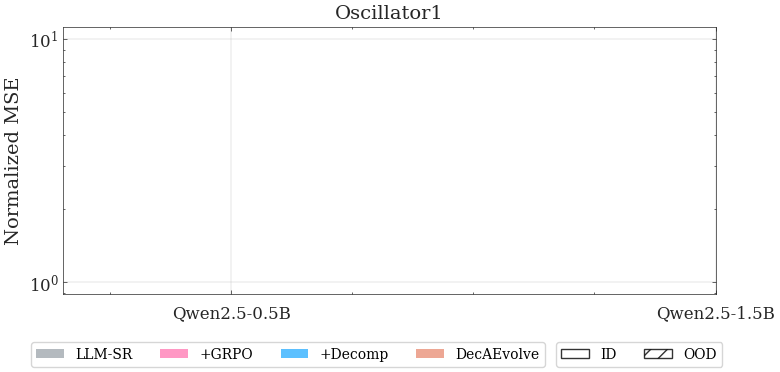

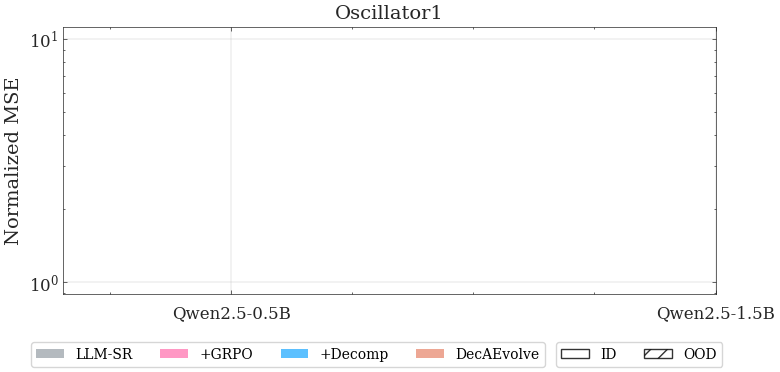

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def create_comparison_barplot():
    # Fix: Ensure all arrays in DataFrame are of the same length (8 for 2 domains x 4 methods)
    id_means = pd.DataFrame({
        'domain': [
            'Qwen2.5-0.5B', 'Qwen2.5-0.5B', 'Qwen2.5-0.5B', 'Qwen2.5-0.5B',
            'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B',
        ],
        'method': [
            'LLM-SR', '+GRPO', '+Decomp', 'DecAEvolve',
            'LLM-SR', '+GRPO', '+Decomp', 'DecAEvolve',
        ],
        #Oscillator1
        'median_nmse': [
            0.0020535036321787845, 0.0022578616001351784, 0.003234122088762386, 2.8515104559452787e-06,   # Oscillator1
            1.8955334870212296e-05, 1.3547777632424706e-10, 8.69622652861603e-07, 1.476429221349961e-10,   # Oscillator1
        ]
        # # #Oscillator2
        # 'median_nmse': [
        #     0.1716241439486218, 0.13175753031363, 0.164957014217872659, 0.06,   # Oscillator2
        #     5.039379539864272e-05, 5.496512227662594e-10, 6.084176536572784e-10, 1.6774734546603405e-10,   # Oscillator2
        # ]
        # #BactGrow
        # 'median_nmse': [
        #     0.7860057668434195, 0.760238704574411, 0.7603671026887362, 0.7290593304675996,   # BactGrow
        #     0.6537859119358005, 0.6410789162041821, 0.6860073082860568, 0.4826650296810399,   # BactGrow
        # ]
        # # #StressStrain
        # 'median_nmse': [
        #     0.23621084051127847, 0.15057501958722808, 0.20756302390046646, 0.08913410647900885,    # StressStrain
        #     0.05478931936625529, 0.026436117757580712, 0.08071355882719158, 0.026717558598583522,   # StressStrain
        # ]

    })

    ood_means = pd.DataFrame({
        'domain': [
            'Qwen2.5-0.5B', 'Qwen2.5-0.5B', 'Qwen2.5-0.5B', 'Qwen2.5-0.5B',
            'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B',
        ],
        'method': [
            'LLM-SR', '+GRPO', '+Decomp', 'DecAEvolve',
            'LLM-SR', '+GRPO', '+Decomp', 'DecAEvolve',
        ],
        # 'median_ood_nmse': [
        #     0.012, 0.008, 0.007, 2.82e-05,   # Qwen2.5-0.5B
        #     5.2e-03, 1.4e-6, 3.6e-06, 5.4e-8,   # Qwen2.5-1.5B
        # ]
        #Oscillator2
        'median_ood_nmse': [
            # 0.221, 0.138, 0.155, 0.065,   # Oscillator2
            # 2.03e-02, 5.4e-4, 6.08e-3, 1.67e-6,   # 
            0.012, 0.008, 0.007, 2.82e-05,   # Oscillator1
            5.2e-03, 1.4e-6, 3.6e-06, 5.4e-8, 
            # 0.801, 0.775, 0.764, 0.731,   # BactGrow
            # 0.78, 0.68, 0.72, 0.52,  
            # 0.28, 0.21, 0.22, 0.11,   # StressStrain
            # 0.15478931936625529, 0.126436117757580712, 0.18071355882719158, 0.04, 
        ]
    })

    domains = ["Qwen2.5-0.5B", "Qwen2.5-1.5B"]

    fig, ax = plt.subplots(figsize=(8, 4))

    n_domains = len(domains)
    methods = model_variants
    n_methods = len(methods)

    # Calculate bar positions with adjusted spacing
    bar_width = 0.3
    domain_padding = 1.2  # Large padding between domains
    id_ood_padding = 0.3  # Moderate padding between ID and OOD groups

    # Calculate the total width needed for all bars in a domain group
    group_width = (n_methods * bar_width * 2) + id_ood_padding  # Width for both ID and OOD groups plus padding

    # Create positions for each domain
    domain_positions = np.arange(n_domains) * (group_width + domain_padding)

    # Create legend elements
    method_patches = []
    for i, method in enumerate(methods):
        color = colors[i]
        method_patches.append(Patch(facecolor=carbon[color]["40"], alpha=0.8, label=method))

    distribution_patches = [
        Patch(facecolor='none', alpha=0.8, edgecolor='black', label='ID'),
        Patch(facecolor='none', alpha=0.8, edgecolor='black', hatch='//', label='OOD')
    ]

    # # Plot bars
    # for i, method in enumerate(methods):
    #     # ID bars - grouped together
    #     id_data = id_means[id_means['method'] == method]
    #     pos_id = domain_positions + (i * bar_width)
    #     color = colors[i]
    #     ax.bar(pos_id,
    #            id_data['median_nmse'],
    #            bar_width,
    #            color=carbon[color]["40"],
    #            alpha=0.7,
    #            edgecolor='black',
    #            linewidth=1,)

    #     # OOD bars - grouped together with padding
    #     ood_data = ood_means[ood_means['method'] == method]
    #     pos_ood = domain_positions + (n_methods * bar_width) + id_ood_padding + (i * bar_width)
    #     color = colors[i]
    #     ax.bar(pos_ood,
    #            ood_data['median_ood_nmse'],
    #            bar_width,
    #            color=carbon[color]["40"],
    #            alpha=0.5,
    #            edgecolor='black',
    #            linewidth=1,
    #            hatch='//')

    ax.grid(axis='x', color=carbon['gray']['40'], lw=0.2)
    ax.grid(axis='y', color=carbon['gray']['40'], lw=0.2)
    ax.set_ylabel(r'Normalized MSE', fontsize=14)

    domain_labels = ["Qwen2.5-0.5B", "Qwen2.5-1.5B"]

    ax.set_xticks(domain_positions + group_width/2)
    ax.set_xticklabels(domain_labels, fontsize=8, ha='center')
    ax.tick_params(axis='x', which='major', pad=8)  # Adds some padding below the labels

    # Also increase y-axis tick label size if desired
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Set y-axis to log scale
    ax.set_yscale('log')
    ax.set_title('Oscillator1', fontsize=14)
    # To set custom y-ticks, use ax.set_yticks() and optionally ax.set_yticklabels()
    # Example: set y-ticks at [0.01, 0.1, 1, 10, 100] for log scale
    # ax.set_yticks([0.01, 0.1, ])
    # ax.set_yticklabels([r'$10^{-2}$', r'$10^{-1}$',])

    # Create two separate legends
    # Methods legend (colors)
    first_legend = ax.legend(ncol=4,
                        handles=method_patches, 
                        #    bbox_to_anchor=(1.01, 0.98),
                           bbox_to_anchor=(-0.05, -0.18),
                           loc='upper left',
                           borderaxespad=0.,
                           frameon=True,)

    # Add the first legend manually
    ax.add_artist(first_legend)

    # Distribution legend (patterns)
    ax.legend(ncol=2,
             handles=distribution_patches,
             bbox_to_anchor=(0.755, -0.18),  # Centered below the figure
             loc='upper left',
             borderaxespad=0.,
             frameon=True,)

    # ax.spines['top'].set_linewidth(2)
    # ax.spines['top'].set_visible(False)
    # ax.spines['bottom'].set_linewidth(1)
    # ax.spines['left'].set_linewidth(1)
    # ax.spines['right'].set_visible(False)

    # from matplotlib.ticker import MaxNLocator
    # ax = plt.gca()
    # ax.yaxis.set_major_locator(MaxNLocator(nbins=10))
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.savefig('./figs/oscillator1_nmse_id_ood_v3.png', dpi=600, bbox_inches='tight', pad_inches=0.6)
    return fig

colors = [
    'coolGray',
    'magenta',
    'cyan',
    'rose'
]
model_variants = [
    "LLM-SR",
    "+GRPO",
    "+Decomp",
    "DecAEvolve",
]
create_comparison_barplot()


## GRPO Rewards

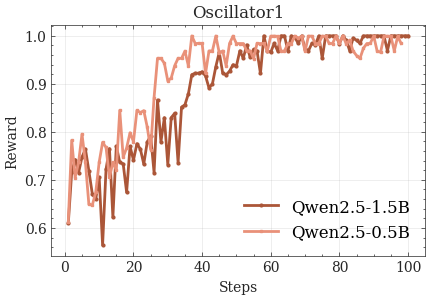

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove any seaborn style that may be set globally
# plt.style.use('default')

# Read the CSV file
df = pd.read_csv('rewards/osc1_rewards.csv')
# df = pd.read_csv('rewards/osc2_rewards.csv')
# df = pd.read_csv('rewards/bg_rewards.csv')
# df = pd.read_csv('rewards/ss_rewards.csv')

# Only plot up to step 100
df = df[df['train/global_step'] <= 100]

# Set up the plot
import matplotlib

matplotlib.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize=(4.5, 3.2))

# Plot rewards for both models
# Model 1: Qwen2.5-1.5B
ax.plot(df['train/global_step'], 
        df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756158958 - train/reward'], #Osc1
        # df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756174399 - train/reward'],  #Osc2
        # df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756182413 - train/reward'],  #BactGrow
        # df['Qwen/Qwen2.5-1.5B-Instruct-r8-g64-1756184995 - train/reward'],  #StressStrain
        color=carbon['rose']['60'],
        label='Qwen2.5-1.5B', linewidth=2, marker='o', markersize=2)

# Model 2: Qwen2.5-0.5B (only plot up to where data exists)
mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1755898769 - train/reward'].notna()
# mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756174705 - train/reward'].notna()
# mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756181910 - train/reward'].notna()
# mask_0_5b = df['Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756185192 - train/reward'].notna()
ax.plot(df.loc[mask_0_5b, 'train/global_step'], 
        df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1755898769 - train/reward'], #Osc1
        # df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756174705 - train/reward'], #Osc2
        # df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756181910 - train/reward'], #Bactgrow
        # df.loc[mask_0_5b, 'Qwen/Qwen2.5-0.5B-Instruct-r8-g64-1756185192 - train/reward'], #StressStrain
        color=carbon['rose']['40'],
        label='Qwen2.5-0.5B', linewidth=2, marker='s', markersize=2)

# Customize the plot
ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator1')
# ax.set_title('Oscillator2')
# ax.set_title('Bactgrow')
# ax.set_title('Stressstrain')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)


# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

# Add some styling
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# Adjust layout and display
plt.tight_layout()

# Save the plot in the ./figs/ directory
plt.savefig('./figs/osc1-rewards.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('./figs/osc2-rewards.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('./figs/bactgrow-rewards.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('./figs/stressstrain-rewards.pdf', dpi=300, bbox_inches='tight')
plt.show()


### Oscillator 1 (Qwen Models)

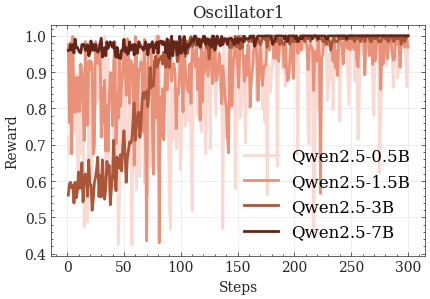

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Define model info: (label, csv_path, reward_column, color, marker)
model_infos = [
    {
        "label": "Qwen2.5-0.5B",
        "csv": "rewards/osc1_qwen0.5b_rewards.csv",
        "col": "Qwen2.5-0.5B_oscillator1 - train/reward",
        "color": carbon['rose']['20'],  # red-ish
        # "marker": "s"
    },
    {
        "label": "Qwen2.5-1.5B",
        "csv": "rewards/osc1_qwen1.5b_rewards.csv",
        "col": "Qwen2.5-1.5B_oscillator1 - train/reward",
        "color": carbon['rose']['40'],  # blue-ish
        # "marker": "o"
    },
    {
        "label": "Qwen2.5-3B",
        "csv": "rewards/osc1_qwen3b_rewards.csv",
        "col": "Qwen2.5-3B_oscillator1 - train/reward",
        "color": carbon['rose']['60'],  # green-ish
        # "marker": "D"
    },
    {
        "label": "Qwen2.5-7B",
        "csv": "rewards/osc1_qwen7b_rewards.csv",
        "col": "Qwen2.5-7B_oscillator1 - train/reward",
        "color": carbon['rose']['80'],  # purple-ish
        # "marker": "^"
    },
]

fig, ax = plt.subplots(figsize=(4.5, 3.2))

endpoint = 300  # Only plot up to this step

for info in model_infos:
    try:
        df = pd.read_csv(info["csv"])
        # Only plot up to step endpoint if available
        if 'train/global_step' in df.columns:
            df = df[df['train/global_step'] <= endpoint]
            x = df['train/global_step'].to_numpy()
        else:
            # fallback: try first column
            x = df.iloc[:, 0].to_numpy()
        # Only plot if the reward column exists
        if info["col"] in df.columns:
            y = df[info["col"]].to_numpy()
            # Only keep points where y > 0.4
            mask = (~np.isnan(y)) & (y > 0.4)
            x_masked = x[mask]
            y_masked = y[mask]
            # If the last x value is less than endpoint, extend with the last y value (if > 0.4)
            if len(x_masked) > 0 and x_masked[-1] < endpoint:
                last_y = y[~np.isnan(y)][-1] if np.any(~np.isnan(y)) else np.nan
                if not np.isnan(last_y) and last_y > 0.4:
                    x_extend = np.arange(x_masked[-1]+1, endpoint+1)
                    y_extend = np.full_like(x_extend, last_y, dtype=float)
                    # Only keep y_extend values where y > 0.4 (should always be true here)
                    extend_mask = (y_extend > 0.4)
                    x_extend = x_extend[extend_mask]
                    y_extend = y_extend[extend_mask]
                    x_masked = np.concatenate([x_masked, x_extend])
                    y_masked = np.concatenate([y_masked, y_extend])
            ax.plot(
                x_masked,
                y_masked,
                color=info["color"],
                label=info["label"],
                linewidth=2,
                # marker=info["marker"],
                markersize=2
            )
    except Exception as e:
        print(f"Could not plot {info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator1')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc1-rewards.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-0.5B 

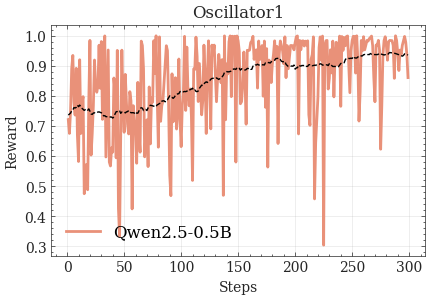

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-0.5B",
    "csv": "rewards/osc1_qwen0.5b_rewards.csv",
    "col": "Qwen2.5-0.5B_oscillator1 - train/reward",
    "color": carbon['rose']['40'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator1')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc1-rewards-0.5b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-1.5B

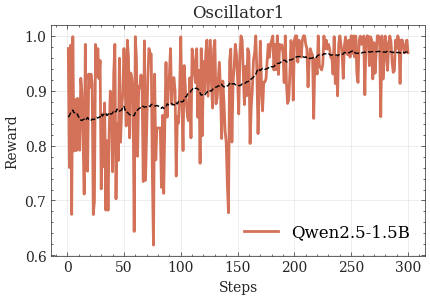

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-1.5B",
    "csv": "rewards/osc1_qwen1.5b_rewards.csv",
    "col": "Qwen2.5-1.5B_oscillator1 - train/reward",
    "color": carbon['rose']['50'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator1')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc1-rewards-1.5b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-3B

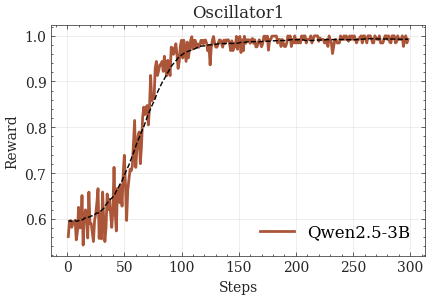

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-3B",
    "csv": "rewards/osc1_qwen3b_rewards.csv",
    "col": "Qwen2.5-3B_oscillator1 - train/reward",
    "color": carbon['rose']['60'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator1')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc1-rewards-3b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-7B

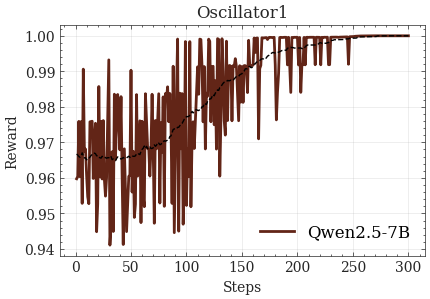

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-7B",
    "csv": "rewards/osc1_qwen7b_rewards.csv",
    "col": "Qwen2.5-7B_oscillator1 - train/reward",
    "color": carbon['rose']['80'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator1')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc1-rewards-7b.pdf', dpi=300, bbox_inches='tight')
plt.show()


### Oscillator 2 (Qwen Models)

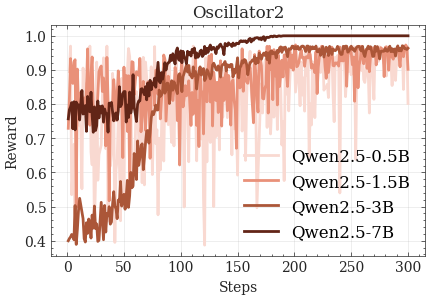

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Define model info: (label, csv_path, reward_column, color, marker)
model_infos = [
    {
        "label": "Qwen2.5-0.5B",
        "csv": "rewards/osc2_qwen0.5b_rewards.csv",
        "col": "Qwen2.5-0.5B_oscillator2 - train/reward",
        "color": carbon['rose']['20'],  # red-ish
        # "marker": "s"
    },
    {
        "label": "Qwen2.5-1.5B",
        "csv": "rewards/osc2_qwen1.5b_rewards.csv",
        "col": "Qwen2.5-1.5B_oscillator2 - train/reward",
        "color": carbon['rose']['40'],  # blue-ish
        # "marker": "o"
    },
    {
        "label": "Qwen2.5-3B",
        "csv": "rewards/osc2_qwen3b_rewards.csv",
        "col": "Qwen2.5-3B_ oscillator2 - train/reward",
        "color": carbon['rose']['60'],  # green-ish
        # "marker": "D"
    },
    {
        "label": "Qwen2.5-7B",
        "csv": "rewards/osc2_qwen7b_rewards.csv",
        "col": "Qwen2.5-7B_oscillator2 - train/reward",
        "color": carbon['rose']['80'],  # purple-ish
        # "marker": "^"
    },
]

fig, ax = plt.subplots(figsize=(4.5, 3.2))

for info in model_infos:
    try:
        df = pd.read_csv(info["csv"])
        # Only plot up to step 300 if available
        if 'train/global_step' in df.columns:
            df = df[df['train/global_step'] <= 300]
            x = df['train/global_step'].to_numpy()
        else:
            # fallback: try first column
            x = df.iloc[:, 0].to_numpy()
        # Only plot if the reward column exists
        if info["col"] in df.columns:
            y = df[info["col"]].to_numpy()
            # Only plot points in the 0.25 to 0.75 percentile and y > 0.5
            lower = np.nanquantile(y, 0.0)
            upper = np.nanquantile(y, 1.0)
            mask = (~np.isnan(y)) & (y >= lower) & (y <= upper) & (y > 0.38)
            # If the last x is less than 300, extend x and y to 300 with the last valid y value
            max_step = 300
            if len(x) > 0 and x[-1] < max_step:
                last_x = x[-1]
                last_y = y[-1]
                # Only extend if last_y is not nan
                if not np.isnan(last_y):
                    x_ext = np.append(x, max_step)
                    y_ext = np.append(y, last_y)
                    # Update mask for the new point
                    mask_ext = np.append(mask, (last_y >= lower) & (last_y <= upper) & (last_y > 0.38))
                    x = x_ext
                    y = y_ext
                    mask = mask_ext
            # Plot only the filtered points
            ax.plot(
                x[mask],
                y[mask],
                color=info["color"],
                label=info["label"],
                linewidth=2,
                # marker=info["marker"],
                markersize=2
            )
    except Exception as e:
        print(f"Could not plot {info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator2')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc2-rewards.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-0.5B

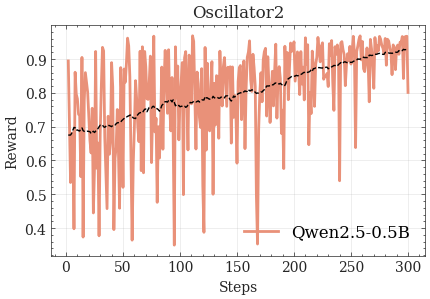

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-0.5B",
    "csv": "rewards/osc2_qwen0.5b_rewards.csv",
    "col": "Qwen2.5-0.5B_oscillator2 - train/reward",
    "color": carbon['rose']['40'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator2')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc2-rewards-0.5b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-1.5B

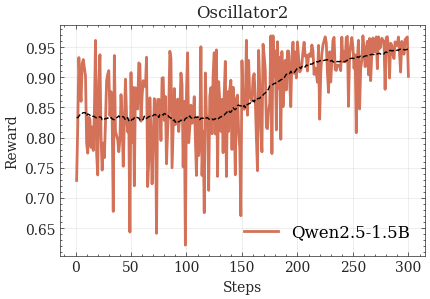

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-1.5B",
    "csv": "rewards/osc2_qwen1.5b_rewards.csv",
    "col": "Qwen2.5-1.5B_oscillator2 - train/reward",
    "color": carbon['rose']['50'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator2')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc2-rewards-1.5b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-3B

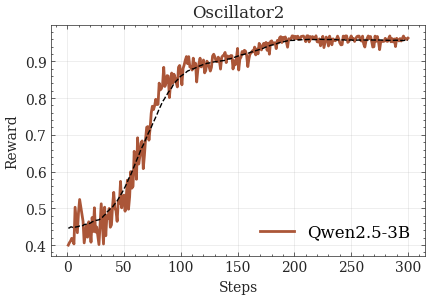

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-3B",
    "csv": "rewards/osc2_qwen3b_rewards.csv",
    "col": "Qwen2.5-3B_ oscillator2 - train/reward",
    "color": carbon['rose']['60'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator2')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc2-rewards-3b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-7B

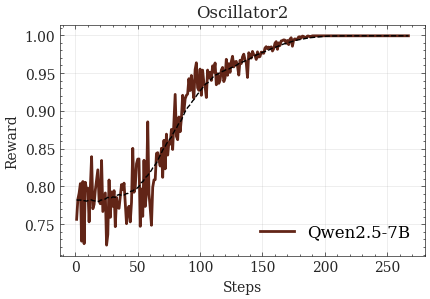

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-7B",
    "csv": "rewards/osc2_qwen7b_rewards.csv",
    "col": "Qwen2.5-7B_oscillator2 - train/reward",
    "color": carbon['rose']['80'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('Oscillator2')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/osc2-rewards-7b.pdf', dpi=300, bbox_inches='tight')
plt.show()


## Bactgrow (Qwen Models)

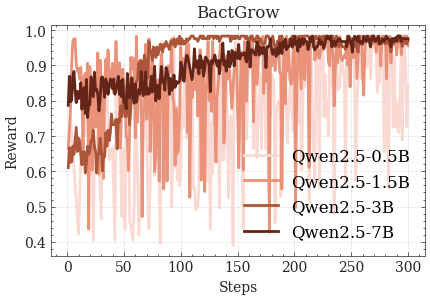

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Define model info: (label, csv_path, reward_column, color, marker)
model_infos = [
    {
        "label": "Qwen2.5-0.5B",
        "csv": "rewards/bg_qwen0.5b_rewards.csv",
        "col": "Qwen2.5-0.5B_bactgrow - train/reward",
        "color": carbon['rose']['20'],  # red-ish
        # "marker": "s"
    },
    {
        "label": "Qwen2.5-1.5B",
        "csv": "rewards/bg_qwen1.5b_rewards.csv",
        "col": "Qwen2.5-1.5B_bactgrow - train/reward",
        "color": carbon['rose']['40'],  # blue-ish
        # "marker": "o"
    },
    {
        "label": "Qwen2.5-3B",
        "csv": "rewards/bg_qwen3b_rewards.csv",
        "col": "Qwen2.5-3B_bactgrow - train/reward",
        "color": carbon['rose']['60'],  # green-ish
        # "marker": "D"
    },
    {
        "label": "Qwen2.5-7B",
        "csv": "rewards/bg_qwen7b_rewards.csv",
        "col": "Qwen2.5-7B_bactgrow - train/reward",
        "color": carbon['rose']['80'],  # purple-ish
        # "marker": "^"
    },
]

fig, ax = plt.subplots(figsize=(4.5, 3.2))

endpoint = 300  # Only plot up to this step

for info in model_infos:
    try:
        df = pd.read_csv(info["csv"])
        # Only plot up to step endpoint if available
        if 'train/global_step' in df.columns:
            df = df[df['train/global_step'] <= endpoint]
            x = df['train/global_step'].to_numpy()
        else:
            # fallback: try first column
            x = df.iloc[:, 0].to_numpy()
        # Only plot if the reward column exists
        if info["col"] in df.columns:
            y = df[info["col"]].to_numpy()
            # Only keep points where y > 0.5
            mask = (~np.isnan(y)) & (y > 0.38)
            x_masked = x[mask]
            y_masked = y[mask]
            # If the last x value is less than endpoint, extend with the last y value (if y > 0.5)
            if len(x_masked) > 0 and x_masked[-1] < endpoint:
                last_y = y[~np.isnan(y)][-1] if np.any(~np.isnan(y)) else np.nan
                if not np.isnan(last_y) and last_y > 0.38:
                    x_extend = np.arange(x_masked[-1]+1, endpoint+1)
                    y_extend = np.full_like(x_extend, last_y, dtype=float)
                    # Only keep y_extend values where y > 0.5 (should always be true if last_y > 0.5)
                    extend_mask = (y_extend > 0.38)
                    x_extend = x_extend[extend_mask]
                    y_extend = y_extend[extend_mask]
                    x_masked = np.concatenate([x_masked, x_extend])
                    y_masked = np.concatenate([y_masked, y_extend])
            ax.plot(
                x_masked,
                y_masked,
                color=info["color"],
                label=info["label"],
                linewidth=2,
                # marker=info["marker"],
                markersize=2
            )
    except Exception as e:
        print(f"Could not plot {info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('BactGrow')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/bg-rewards.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qweun-0.5B

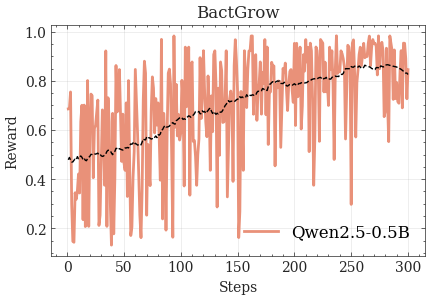

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-0.5B",
    "csv": "rewards/bg_qwen0.5b_rewards.csv",
    "col": "Qwen2.5-0.5B_bactgrow - train/reward",
    "color": carbon['rose']['40'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('BactGrow')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/bg-rewards-0.5b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-1.5B

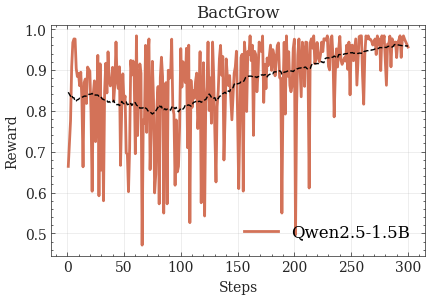

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-1.5B",
    "csv": "rewards/bg_qwen1.5b_rewards.csv",
    "col": "Qwen2.5-1.5B_bactgrow - train/reward",
    "color": carbon['rose']['50'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('BactGrow')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/bg-rewards-1.5b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-3B

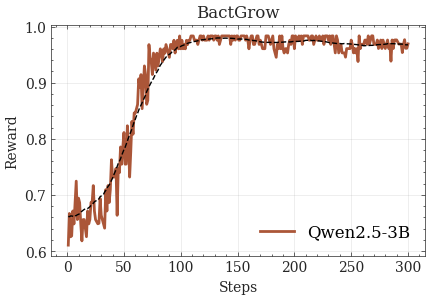

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-3B",
    "csv": "rewards/bg_qwen3b_rewards.csv",
    "col": "Qwen2.5-3B_bactgrow - train/reward",
    "color": carbon['rose']['60'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('BactGrow')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/bg-rewards-3b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-7B

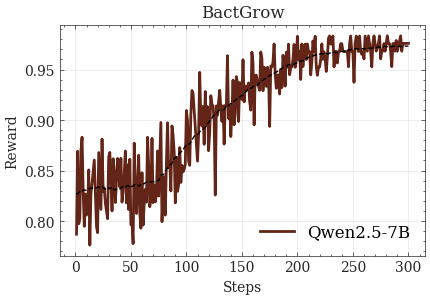

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-7B",
    "csv": "rewards/bg_qwen7b_rewards.csv",
    "col": "Qwen2.5-7B_bactgrow - train/reward",
    "color": carbon['rose']['80'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('BactGrow')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/bg-rewards-7b.pdf', dpi=300, bbox_inches='tight')
plt.show()


## StressStrain (Qwen Models)

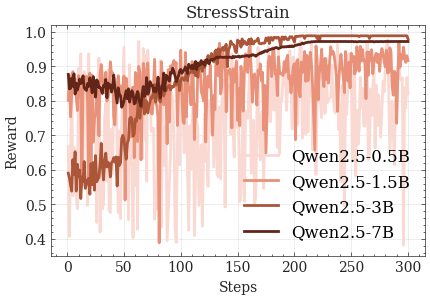

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Define model info: (label, csv_path, reward_column, color, marker)
model_infos = [
    {
        "label": "Qwen2.5-0.5B",
        "csv": "rewards/ss_qwen0.5b_rewards.csv",
        "col": "Qwen2.5-0.5B_stressstrain - train/reward",
        "color": carbon['rose']['20'],  # red-ish
        # "marker": "s"
    },
    {
        "label": "Qwen2.5-1.5B",
        "csv": "rewards/ss_qwen1.5b_rewards.csv",
        "col": "Qwen2.5-1.5B_stressstrain - train/reward",
        "color": carbon['rose']['40'],  # blue-ish
        # "marker": "o"
    },
    {
        "label": "Qwen2.5-3B",
        "csv": "rewards/ss_qwen3b_rewards.csv",
        "col": "Qwen2.5-3B_ stressstrain - train/reward",
        "color": carbon['rose']['60'],  # green-ish
        # "marker": "D"
    },
    {
        "label": "Qwen2.5-7B",
        "csv": "rewards/ss_qwen7b_rewards.csv",
        "col": "Qwen2.5-7B_stressstrain - train/reward",
        "color": carbon['rose']['80'],  # purple-ish
        # "marker": "^"
    },
]

fig, ax = plt.subplots(figsize=(4.5, 3.2))

endpoint = 300  # Only plot up to this step

for info in model_infos:
    try:
        df = pd.read_csv(info["csv"])
        # Only plot up to step endpoint if available
        if 'train/global_step' in df.columns:
            df = df[df['train/global_step'] <= endpoint]
            x = df['train/global_step'].to_numpy()
        else:
            # fallback: try first column
            x = df.iloc[:, 0].to_numpy()
        # Only plot if the reward column exists
        if info["col"] in df.columns:
            y = df[info["col"]].to_numpy()
            # Only keep points where y > 0.5
            mask = (~np.isnan(y)) & (y > 0.38)
            x_masked = x[mask]
            y_masked = y[mask]
            # If the last x value is less than endpoint, extend with the last y value (if y > 0.5)
            if len(x_masked) > 0 and x_masked[-1] < endpoint:
                last_y = y[~np.isnan(y)][-1] if np.any(~np.isnan(y)) else np.nan
                if not np.isnan(last_y) and last_y > 0.38:
                    x_extend = np.arange(x_masked[-1]+1, endpoint+1)
                    y_extend = np.full_like(x_extend, last_y, dtype=float)
                    # Only keep y_extend values where y > 0.5 (should always be true if last_y > 0.5)
                    extend_mask = (y_extend > 0.38)
                    x_extend = x_extend[extend_mask]
                    y_extend = y_extend[extend_mask]
                    x_masked = np.concatenate([x_masked, x_extend])
                    y_masked = np.concatenate([y_masked, y_extend])
            ax.plot(
                x_masked,
                y_masked,
                color=info["color"],
                label=info["label"],
                linewidth=2,
                # marker=info["marker"],
                markersize=2
            )
    except Exception as e:
        print(f"Could not plot {info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('StressStrain')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/ss-rewards.pdf', dpi=300, bbox_inches='tight')
plt.show()


### Qwen-0.5B

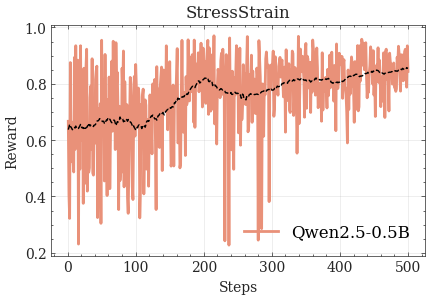

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-0.5B",
    "csv": "rewards/ss_qwen0.5b_rewards.csv",
    "col": "Qwen2.5-0.5B_stressstrain - train/reward",
    "color": carbon['rose']['40'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 500]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('StressStrain')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/ss-rewards-0.5b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-1.5B

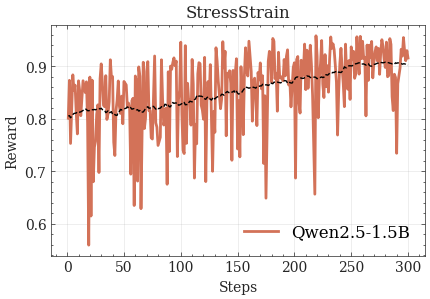

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-1.5B",
    "csv": "rewards/ss_qwen1.5b_rewards.csv",
    "col": "Qwen2.5-1.5B_stressstrain - train/reward",
    "color": carbon['rose']['50'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('StressStrain')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/ss-rewards-1.5b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-3B

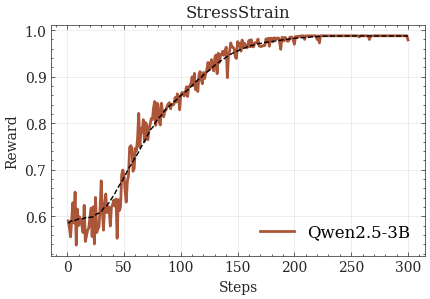

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-3B",
    "csv": "rewards/ss_qwen3b_rewards.csv",
    "col": "Qwen2.5-3B_ stressstrain - train/reward",
    "color": carbon['rose']['60'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('StressStrain')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/ss-rewards-3b.pdf', dpi=300, bbox_inches='tight')
plt.show()


#### Qwen-7B

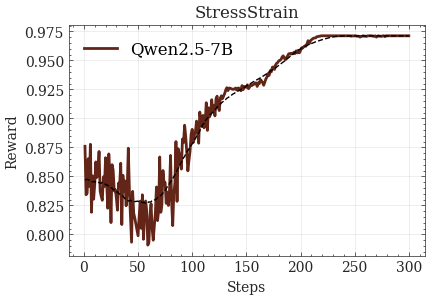

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['text.usetex'] = False

# Only plot for 0.5B model due to noise, and only within 0.75 percentile of reward values
model_info = {
    "label": "Qwen2.5-7B",
    "csv": "rewards/ss_qwen7b_rewards.csv",
    "col": "Qwen2.5-7B_stressstrain - train/reward",
    "color": carbon['rose']['80'],  # red-ish
    # "marker": "s"
}

fig, ax = plt.subplots(figsize=(4.5, 3.2))

try:
    df = pd.read_csv(model_info["csv"])
    # Only plot up to step 350 if available
    if 'train/global_step' in df.columns:
        df = df[df['train/global_step'] <= 300]
        x = df['train/global_step']
    else:
        x = df.iloc[:, 0]
    # Only plot if the reward column exists
    if model_info["col"] in df.columns:
        y = df[model_info["col"]]
        # Filter to only points within the 0.75 percentile
        lower = y.quantile(0.01)
        upper = y.quantile(0.99)
        mask = y.notna() & (y >= lower) & (y <= upper)
        # Plot the noisy curve
        ax.plot(
            x[mask],
            y[mask],
            color=model_info["color"],
            label=model_info["label"],
            linewidth=2,
            # marker=model_info["marker"],
            markersize=2
        )
        # Compute and plot the mean curve (moving average)
        window = 50  # You can adjust the window size for smoothing
        # Use rolling mean only on the filtered data
        y_smooth = y[mask].rolling(window=window, min_periods=5, center=True).mean()
        ax.plot(
            x[mask],
            y_smooth,
            color='black',
            linestyle='--',
            linewidth=1.0,
            # label="Mean (moving avg)"
        )
except Exception as e:
    print(f"Could not plot {model_info['label']}: {e}")

ax.set_xlabel('Steps')
ax.set_ylabel('Reward')
ax.set_title('StressStrain')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Format x-axis to show steps in thousands
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.savefig('./figs/ss-rewards-7b.pdf', dpi=300, bbox_inches='tight')
plt.show()
